# HAWQ vs HAWQ-v2 vs Uniform Quantization — Unified Comparison

This notebook runs **seven pipelines** on a single fine-tuned DeiT-small + Tiny-ImageNet setup:

| | Method | Bit allocation | QAT? |
|---|---|---|---|
| A | FP32 baseline | — | no |
| B | Uniform PTQ | same bits everywhere | no |
| C | Uniform QAT | same bits everywhere | yes |
| D | HAWQ-v1 PTQ | top eigenvalue (Mykhailo's analyzer) | no |
| E | HAWQ-v1 QAT | top eigenvalue | yes |
| F | HAWQ-v2 PTQ | Hutchinson trace (Sandra's analyzer) | no |
| G | HAWQ-v2 QAT | Hutchinson trace | yes |

**Dataset**: Tiny-ImageNet (200 classes, 64×64 → 224×224)
**Model**: facebook/deit-small-patch16-224 (22M params)
**Quantization**: weight-only, candidate bits {4, 5, 6, 7, 8}

**Outputs**: `compare/results.csv`, `compare/bit_assignments.json`, `compare/plots/*.png`

## 1. Imports — load both `hawq/` and `hawq-v2/` modules without naming collisions

In [20]:
import sys, os, copy, json, time
from pathlib import Path
import importlib.util

REPO_ROOT = Path('.').resolve()
OUT_DIR = REPO_ROOT / 'compare'
PLOTS_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

# v2 modules: importable normally because hawq-v2 has no name collision once on path
sys.path.insert(0, str(REPO_ROOT / 'hawq-v2'))
import quantizer as v2_quant            # noqa: E402
import analyzer_v2                      # noqa: E402
import bit_allocator as v2_bit_alloc    # noqa: E402
import ptq                              # noqa: E402
import data as v2_data                  # noqa: E402

# v1 modules: load via importlib so they don't shadow the v2 imports.
def _load(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    m = importlib.util.module_from_spec(spec)
    sys.modules[name] = m
    spec.loader.exec_module(m)
    return m

v1_analyzer = _load('v1_analyzer', str(REPO_ROOT / 'hawq' / 'analyzer.py'))
v1_bit_alloc = _load('v1_bit_alloc', str(REPO_ROOT / 'hawq' / 'bit_allocator.py'))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from transformers import AutoModelForImageClassification
from torch.utils.data import DataLoader

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')
print(f'Device: {device}')
print(f'Output dir: {OUT_DIR}')

Device: cuda
Output dir: /workspace/Hessian-Based-Mixed-Precision-Quantization/compare


## 2. Config

All experiment knobs live here. Tune for your time budget.

In [21]:
# ---------- Data ----------
TRAIN_SUBSET = 30000     # used for QAT recovery + fallback fine-tune
VAL_SUBSET   = 5000      # full reliable accuracy reporting
BATCH_SIZE   = 64

# ---------- Fine-tune (only if checkpoint missing) ----------
FT_EPOCHS = 5
FT_LR     = 5e-5

# ---------- Quantization ----------
BUDGETS      = [4.5, 5, 5.5, 6]      # all bit budgets we'll measure
QAT_BUDGETS  = [4, 5]            # subset that gets QAT recovery (time-bounded)
CANDIDATE_BITS = (8, 6, 5, 4)          # bit-widths the allocators may pick from

# ---------- QAT recovery ----------
QAT_EPOCHS   = 1
QAT_LR       = 1e-5
QAT_TRAIN_SUBSET = 30000            # smaller -> faster QAT runs

# ---------- HAWQ analysers ----------
HAWQ_NUM_SAMPLES = 8                # Hutchinson Rademacher samples per batch
HAWQ_NUM_BATCHES = 2                # batches averaged per layer
ANALYZER_BATCH_SIZE = 8             # tiny batch for second-order autograd (avoids OOM)

# ---------- Paths ----------
CHECKPOINT_PATH = REPO_ROOT / 'hawq-v2' / 'checkpoint.pt'
MODEL_NAME = 'facebook/deit-small-patch16-224'

print('Config locked. Estimated runtime on 5070 Ti:')
print(f'  with checkpoint:    ~25-30 min')
print(f'  without checkpoint: ~45-50 min (adds {FT_EPOCHS}-epoch fine-tune)')

Config locked. Estimated runtime on 5070 Ti:
  with checkpoint:    ~25-30 min
  without checkpoint: ~45-50 min (adds 5-epoch fine-tune)


## 3. Data

In [22]:
train_loader, val_loader, num_classes = v2_data.load_tiny_imagenet(
    batch_size=BATCH_SIZE,
    num_workers=2,
    image_size=224,
    train_subset=TRAIN_SUBSET,
    val_subset=VAL_SUBSET,
)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

# Tiny separate loader for the second-order Hutchinson trace (memory-bounded)
analyzer_loader = DataLoader(
    val_loader.dataset,
    batch_size=ANALYZER_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

Train batches: 469 | Val batches: 79


## 4. Model — load checkpoint or fast fine-tune

In [23]:
def build_model():
    """Fresh DeiT-small with a 200-class head and eager attention
    (eager is required so HAWQ-v2's second-order autograd works)."""
    return AutoModelForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_classes,
        ignore_mismatched_sizes=True,
        attn_implementation='eager',
    ).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

model = build_model()
n_params = sum(p.numel() for p in model.parameters())
print(f'Total params: {n_params:,}')

# Try to load existing checkpoint
checkpoint_loaded = False
if CHECKPOINT_PATH.exists():
    try:
        ckpt = torch.load(str(CHECKPOINT_PATH), map_location=device, weights_only=False)
        target_names_ckpt = ckpt.get('target_names', [])
        # Wrap matching layers and load full state
        v2_quant.replace_linear_with_qlinear(model, target_names_ckpt)
        model.load_state_dict(ckpt['state_dict'])
        model = model.to(device)
        checkpoint_loaded = True
        print(f'Loaded checkpoint from {CHECKPOINT_PATH}')
    except Exception as e:
        print(f'Could not load checkpoint ({e}). Will fine-tune from ImageNet weights.')
        model = build_model()

if not checkpoint_loaded:
    print(f'\nFast fine-tune: {FT_EPOCHS} epochs at lr={FT_LR} ...')
    for p in model.parameters():
        p.requires_grad = True
    optimizer = torch.optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=FT_EPOCHS * len(train_loader), eta_min=1e-6,
    )
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

    for epoch in range(FT_EPOCHS):
        model.train()
        total = 0.0
        for inputs, targets in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            optimizer.zero_grad()
            if scaler is not None:
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    out = model(inputs)
                    logits = out.logits if hasattr(out, 'logits') else out
                    loss = criterion(logits, targets)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                out = model(inputs)
                logits = out.logits if hasattr(out, 'logits') else out
                loss = criterion(logits, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()
            total += loss.item()
        print(f'  epoch {epoch+1}/{FT_EPOCHS}: loss={total/len(train_loader):.4f}')

    for p in model.parameters():
        p.requires_grad = True
    print('Fine-tune done.')

[transformers] You passed `num_labels=200` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: facebook/deit-small-patch16-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([200])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([200, 384])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Total params: 21,742,664

Fast fine-tune: 5 epochs at lr=5e-05 ...
  epoch 1/5: loss=1.8769
  epoch 2/5: loss=1.1311
  epoch 3/5: loss=1.0147
  epoch 4/5: loss=0.9477
  epoch 5/5: loss=0.9162
Fine-tune done.


## 5. Wrap target Linear blocks in QLinear

All seven pipelines share the same QLinear-wrapped backbone. The classifier head stays in FP32.
If the checkpoint already has QLinear in place, this no-ops.

In [24]:
if not any(isinstance(m, v2_quant.QLinear) for m in model.modules()):
    target_names = [
        name for name, m in model.named_modules()
        if isinstance(m, nn.Linear)
        and 'classifier' not in name.lower()
        and 'head' not in name.lower()
    ]
    v2_quant.replace_linear_with_qlinear(model, target_names)
    model = model.to(device)
else:
    target_names = [
        name for name, m in model.named_modules()
        if isinstance(m, v2_quant.QLinear)
    ]

params_per_layer = ptq.collect_qlinear_param_counts(model)
print(f'QLinear blocks: {len(params_per_layer)}')

# Snapshot the pristine FP32 weights so every pipeline can restart from the same point.
ptq.disable_all_quantization(model)
fp32_state = copy.deepcopy(model.state_dict())
fp32_size_mb = sum(p.numel() for p in model.parameters()) * 4 / (1024 ** 2)
print(f'FP32 model size (all FP32): {fp32_size_mb:.2f} MB')

QLinear blocks: 72
FP32 model size (all FP32): 82.94 MB


## 6. Pipeline A — FP32 baseline accuracy

In [25]:
fp32_acc = ptq.evaluate(model, val_loader, device=device)
print(f'FP32 accuracy: {fp32_acc*100:.2f}%')

FP32 accuracy: 54.90%


## 7. HAWQ-v1 sensitivity (top eigenvalue)

Mykhailo's `ViTHAWQAnalyzer` from `hawq/analyzer.py`.

In [26]:
torch.cuda.empty_cache() if device.type == 'cuda' else None

v1_an = v1_analyzer.ViTHAWQAnalyzer(model, analyzer_loader, criterion)

target_blocks = {
    name: m for name, m in model.named_modules()
    if isinstance(m, v2_quant.QLinear)
}

t0 = time.time()
sens_v1 = v1_an.compute_layer_sensitivities(
    target_blocks=target_blocks,
    num_batches=HAWQ_NUM_BATCHES,
    sort_desc=True,
    verbose=False,
)
print(f'HAWQ-v1 sensitivity done in {time.time()-t0:.1f}s for {len(sens_v1)} layers')

with open(OUT_DIR / 'sensitivities_v1.json', 'w') as f:
    json.dump(sens_v1, f, indent=2)
torch.cuda.empty_cache() if device.type == 'cuda' else None

Using device: cuda
HAWQ-v1 sensitivity done in 45.8s for 72 layers


## 8. HAWQ-v2 sensitivity (Hutchinson trace)

Sandra's `ViTHAWQv2Analyzer` from `hawq-v2/analyzer_v2.py`.

In [27]:
v2_an = analyzer_v2.ViTHAWQv2Analyzer(model, analyzer_loader, criterion)

t0 = time.time()
sens_v2 = v2_an.compute_layer_sensitivities(
    target_blocks=target_blocks,
    num_samples=HAWQ_NUM_SAMPLES,
    num_batches=HAWQ_NUM_BATCHES,
    sort_desc=True,
    verbose=False,
)
print(f'HAWQ-v2 sensitivity done in {time.time()-t0:.1f}s for {len(sens_v2)} layers')

with open(OUT_DIR / 'sensitivities_v2.json', 'w') as f:
    json.dump(sens_v2, f, indent=2)
torch.cuda.empty_cache() if device.type == 'cuda' else None

[HAWQ-v2] Using device: cuda
HAWQ-v2 sensitivity done in 42.0s for 72 layers


## 9. Helpers — budget allocation, QAT recovery, scoring

In [28]:
def allocate_by_budget(sensitivities, target_avg_bits, candidate_bits=CANDIDATE_BITS):
    """Pass-based parameter-weighted allocator.

    Walks adjacent (low->high) bit-width pairs in passes; within each pass
    promotes layers in sensitivity order. Avoids the polarisation that
    depth-first allocation produces at intermediate budgets.
    """
    bits_asc = sorted(set(int(b) for b in candidate_bits))
    min_bit, max_bit = bits_asc[0], bits_asc[-1]
    if target_avg_bits >= max_bit:
        return {n: max_bit for n in sensitivities}
    if target_avg_bits <= min_bit:
        return {n: min_bit for n in sensitivities}

    sorted_layers = sorted(
        sensitivities.items(),
        key=lambda x: x[1]['S_i'],
        reverse=True,
    )
    layer_names = [n for n, _ in sorted_layers]
    params = {n: meta['parameters'] for n, meta in sorted_layers}
    total_p = sum(params.values())

    allocated = {n: min_bit for n in layer_names}

    def avg(a):
        return sum(a[n] * params[n] for n in layer_names) / total_p

    for i in range(len(bits_asc) - 1):
        cur, nxt = bits_asc[i], bits_asc[i + 1]
        for name in layer_names:
            if allocated[name] != cur:
                continue
            tentative = dict(allocated); tentative[name] = nxt
            new_a, cur_a = avg(tentative), avg(allocated)
            if new_a <= target_avg_bits:
                allocated = tentative
                continue
            if abs(new_a - target_avg_bits) < abs(cur_a - target_avg_bits):
                allocated = tentative
            return allocated
    return allocated


def restore_fp32():
    """Reset model weights and turn off all quantizers — every pipeline starts here."""
    model.load_state_dict(fp32_state)
    ptq.disable_all_quantization(model)


def qat_recover(bit_assign, epochs=QAT_EPOCHS, lr=QAT_LR, train_subset=QAT_TRAIN_SUBSET):
    """Apply quantization, run a short fine-tune so weights heal around the grid."""
    ptq.apply_bit_assignment(model, bit_assign, quantize_activations=False)
    for p in model.parameters():
        p.requires_grad = True

    qat_loader, _, _ = v2_data.load_tiny_imagenet(
        batch_size=BATCH_SIZE, num_workers=2, image_size=224,
        train_subset=train_subset, val_subset=128,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

    model.train()
    for epoch in range(epochs):
        for inputs, targets in qat_loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            optimizer.zero_grad()
            if scaler is not None:
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    out = model(inputs)
                    logits = out.logits if hasattr(out, 'logits') else out
                    loss = criterion(logits, targets)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                out = model(inputs)
                logits = out.logits if hasattr(out, 'logits') else out
                loss = criterion(logits, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
    return ptq.evaluate(model, val_loader, device=device)


results = []
bit_assignments = {}

results.append({
    'pipeline': 'A',
    'method': 'FP32',
    'avg_bits': 32.0,
    'accuracy': fp32_acc,
    'size_mb': fp32_size_mb,
    'qat': False,
})
print('helpers loaded; results table seeded with FP32 baseline')

helpers loaded; results table seeded with FP32 baseline


## 10. Pipelines B & C — Uniform PTQ + Uniform QAT

In [29]:
# --- Pipeline B: Uniform PTQ ---
for bits in BUDGETS:
    restore_fp32()
    bit_assign = {n: int(bits) for n in params_per_layer}
    ptq.apply_bit_assignment(model, bit_assign, quantize_activations=False)
    acc = ptq.evaluate(model, val_loader, device=device)
    size_mb = ptq.compute_effective_size(model, bit_assign)
    avg_b = ptq.average_bits(bit_assign, params_per_layer)
    results.append({
        'pipeline': 'B', 'method': f'Uniform-{bits}-PTQ',
        'avg_bits': avg_b, 'accuracy': acc, 'size_mb': size_mb, 'qat': False,
    })
    bit_assignments[f'Uniform-{bits}-PTQ'] = bit_assign
    print(f'  Uniform-{bits} PTQ: acc={acc*100:.2f}% | size={size_mb:.2f}MB')

# --- Pipeline C: Uniform QAT ---
for bits in QAT_BUDGETS:
    restore_fp32()
    bit_assign = {n: int(bits) for n in params_per_layer}
    t0 = time.time()
    acc = qat_recover(bit_assign)
    size_mb = ptq.compute_effective_size(model, bit_assign)
    avg_b = ptq.average_bits(bit_assign, params_per_layer)
    results.append({
        'pipeline': 'C', 'method': f'Uniform-{bits}-QAT',
        'avg_bits': avg_b, 'accuracy': acc, 'size_mb': size_mb, 'qat': True,
    })
    bit_assignments[f'Uniform-{bits}-QAT'] = bit_assign
    print(f'  Uniform-{bits} QAT: acc={acc*100:.2f}% | size={size_mb:.2f}MB | took {time.time()-t0:.0f}s')

  Uniform-4.5 PTQ: acc=4.80% | size=12.07MB
  Uniform-5 PTQ: acc=49.68% | size=14.60MB
  Uniform-5.5 PTQ: acc=49.68% | size=14.60MB
  Uniform-6 PTQ: acc=54.10% | size=17.13MB
  Uniform-4 QAT: acc=45.08% | size=12.07MB | took 61s
  Uniform-5 QAT: acc=53.56% | size=14.60MB | took 60s


## 11. Pipelines D & E — HAWQ-v1 PTQ + QAT

In [30]:
# --- Pipeline D: HAWQ-v1 PTQ ---
for bits in BUDGETS:
    restore_fp32()
    bit_assign = allocate_by_budget(sens_v1, float(bits))
    ptq.apply_bit_assignment(model, bit_assign, quantize_activations=False)
    acc = ptq.evaluate(model, val_loader, device=device)
    size_mb = ptq.compute_effective_size(model, bit_assign)
    avg_b = ptq.average_bits(bit_assign, params_per_layer)
    results.append({
        'pipeline': 'D', 'method': f'HAWQv1-{bits}-PTQ',
        'avg_bits': avg_b, 'accuracy': acc, 'size_mb': size_mb, 'qat': False,
    })
    bit_assignments[f'HAWQv1-{bits}-PTQ'] = bit_assign
    print(f'  HAWQ-v1 budget={bits} PTQ: avg={avg_b:.2f} | acc={acc*100:.2f}% | size={size_mb:.2f}MB')

# --- Pipeline E: HAWQ-v1 QAT ---
for bits in QAT_BUDGETS:
    restore_fp32()
    bit_assign = allocate_by_budget(sens_v1, float(bits))
    t0 = time.time()
    acc = qat_recover(bit_assign)
    size_mb = ptq.compute_effective_size(model, bit_assign)
    avg_b = ptq.average_bits(bit_assign, params_per_layer)
    results.append({
        'pipeline': 'E', 'method': f'HAWQv1-{bits}-QAT',
        'avg_bits': avg_b, 'accuracy': acc, 'size_mb': size_mb, 'qat': True,
    })
    bit_assignments[f'HAWQv1-{bits}-QAT'] = bit_assign
    print(f'  HAWQ-v1 budget={bits} QAT: avg={avg_b:.2f} | acc={acc*100:.2f}% | size={size_mb:.2f}MB | took {time.time()-t0:.0f}s')

  HAWQ-v1 budget=4.5 PTQ: avg=4.51 | acc=30.86% | size=13.35MB
  HAWQ-v1 budget=5 PTQ: avg=5.00 | acc=49.68% | size=14.60MB
  HAWQ-v1 budget=5.5 PTQ: avg=5.51 | acc=52.28% | size=15.88MB
  HAWQ-v1 budget=6 PTQ: avg=6.00 | acc=54.10% | size=17.13MB
  HAWQ-v1 budget=4 QAT: avg=4.00 | acc=45.32% | size=12.07MB | took 61s
  HAWQ-v1 budget=5 QAT: avg=5.00 | acc=53.08% | size=14.60MB | took 61s


## 12. Pipelines F & G — HAWQ-v2 PTQ + QAT

In [31]:
# --- Pipeline F: HAWQ-v2 PTQ ---
for bits in BUDGETS:
    restore_fp32()
    bit_assign = allocate_by_budget(sens_v2, float(bits))
    ptq.apply_bit_assignment(model, bit_assign, quantize_activations=False)
    acc = ptq.evaluate(model, val_loader, device=device)
    size_mb = ptq.compute_effective_size(model, bit_assign)
    avg_b = ptq.average_bits(bit_assign, params_per_layer)
    results.append({
        'pipeline': 'F', 'method': f'HAWQv2-{bits}-PTQ',
        'avg_bits': avg_b, 'accuracy': acc, 'size_mb': size_mb, 'qat': False,
    })
    bit_assignments[f'HAWQv2-{bits}-PTQ'] = bit_assign
    print(f'  HAWQ-v2 budget={bits} PTQ: avg={avg_b:.2f} | acc={acc*100:.2f}% | size={size_mb:.2f}MB')

# --- Pipeline G: HAWQ-v2 QAT ---
for bits in QAT_BUDGETS:
    restore_fp32()
    bit_assign = allocate_by_budget(sens_v2, float(bits))
    t0 = time.time()
    acc = qat_recover(bit_assign)
    size_mb = ptq.compute_effective_size(model, bit_assign)
    avg_b = ptq.average_bits(bit_assign, params_per_layer)
    results.append({
        'pipeline': 'G', 'method': f'HAWQv2-{bits}-QAT',
        'avg_bits': avg_b, 'accuracy': acc, 'size_mb': size_mb, 'qat': True,
    })
    bit_assignments[f'HAWQv2-{bits}-QAT'] = bit_assign
    print(f'  HAWQ-v2 budget={bits} QAT: avg={avg_b:.2f} | acc={acc*100:.2f}% | size={size_mb:.2f}MB | took {time.time()-t0:.0f}s')

  HAWQ-v2 budget=4.5 PTQ: avg=4.50 | acc=30.48% | size=13.33MB
  HAWQ-v2 budget=5 PTQ: avg=5.00 | acc=49.68% | size=14.60MB
  HAWQ-v2 budget=5.5 PTQ: avg=5.50 | acc=51.82% | size=15.86MB
  HAWQ-v2 budget=6 PTQ: avg=6.00 | acc=54.10% | size=17.13MB
  HAWQ-v2 budget=4 QAT: avg=4.00 | acc=44.96% | size=12.07MB | took 60s
  HAWQ-v2 budget=5 QAT: avg=5.00 | acc=53.12% | size=14.60MB | took 61s


## 13. Master results table

In [32]:
df = pd.DataFrame(results)
df['delta_vs_fp32'] = (df['accuracy'] - fp32_acc) * 100
df['compression_x'] = fp32_size_mb / df['size_mb']
df_sorted = df.sort_values(['qat', 'avg_bits', 'method']).reset_index(drop=True)

print(df_sorted.to_string(index=False))
df_sorted.to_csv(OUT_DIR / 'results.csv', index=False)

with open(OUT_DIR / 'bit_assignments.json', 'w') as f:
    json.dump(bit_assignments, f, indent=2)

print(f'\nSaved: {OUT_DIR/"results.csv"}')
print(f'Saved: {OUT_DIR/"bit_assignments.json"}')

pipeline          method  avg_bits  accuracy   size_mb   qat  delta_vs_fp32  compression_x
       B Uniform-4.5-PTQ  4.000000    0.0480 12.066681 False         -50.10       6.873612
       F  HAWQv2-4.5-PTQ  4.500000    0.3048 13.332306 False         -24.42       6.221105
       D  HAWQv1-4.5-PTQ  4.506944    0.3086 13.349884 False         -24.04       6.212914
       D    HAWQv1-5-PTQ  5.000000    0.4968 14.597931 False          -5.22       5.681742
       F    HAWQv2-5-PTQ  5.000000    0.4968 14.597931 False          -5.22       5.681742
       B   Uniform-5-PTQ  5.000000    0.4968 14.597931 False          -5.22       5.681742
       B Uniform-5.5-PTQ  5.000000    0.4968 14.597931 False          -5.22       5.681742
       F  HAWQv2-5.5-PTQ  5.500000    0.5182 15.863556 False          -3.08       5.228442
       D  HAWQv1-5.5-PTQ  5.506944    0.5228 15.881134 False          -2.62       5.222655
       D    HAWQv1-6-PTQ  6.000000    0.5410 17.129181 False          -0.80       4.842128

## 14. Plot 1 — Accuracy vs Average Bit-Width

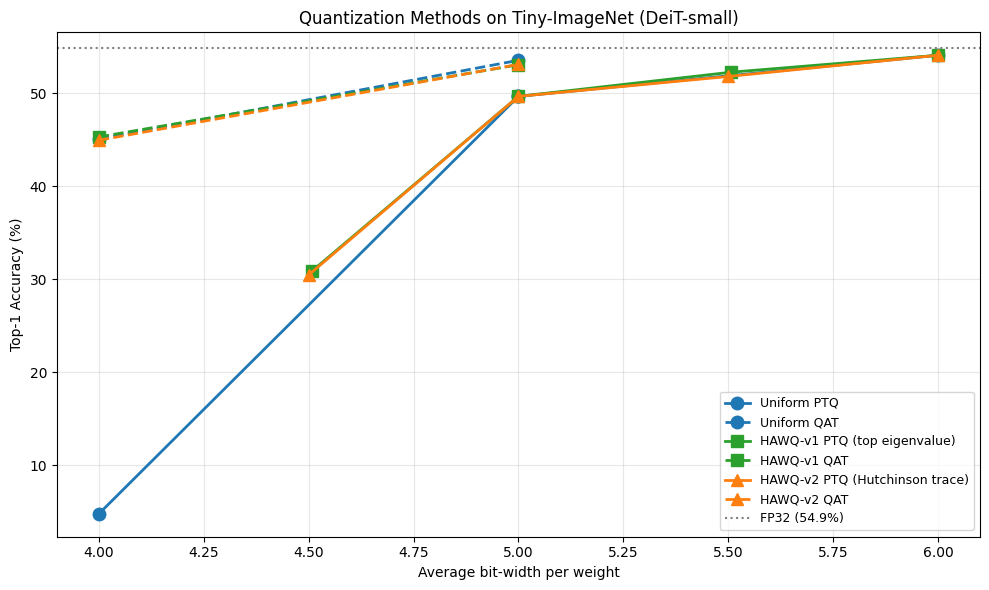

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

styles = {
    'Uniform-PTQ':  dict(color='#1f77b4', marker='o', linestyle='-',  label='Uniform PTQ'),
    'Uniform-QAT':  dict(color='#1f77b4', marker='o', linestyle='--', label='Uniform QAT'),
    'HAWQv1-PTQ':   dict(color='#2ca02c', marker='s', linestyle='-',  label='HAWQ-v1 PTQ (top eigenvalue)'),
    'HAWQv1-QAT':   dict(color='#2ca02c', marker='s', linestyle='--', label='HAWQ-v1 QAT'),
    'HAWQv2-PTQ':   dict(color='#ff7f0e', marker='^', linestyle='-',  label='HAWQ-v2 PTQ (Hutchinson trace)'),
    'HAWQv2-QAT':   dict(color='#ff7f0e', marker='^', linestyle='--', label='HAWQ-v2 QAT'),
}

def slice_by_method(prefix, qat):
    suffix = '-QAT' if qat else '-PTQ'
    sub = df[df['method'].str.startswith(prefix) & df['method'].str.endswith(suffix)].sort_values('avg_bits')
    return sub

for prefix, qat in [
    ('Uniform', False), ('Uniform', True),
    ('HAWQv1', False), ('HAWQv1', True),
    ('HAWQv2', False), ('HAWQv2', True),
]:
    sub = slice_by_method(prefix, qat)
    if len(sub) == 0:
        continue
    key = f'{prefix}-' + ('QAT' if qat else 'PTQ')
    ax.plot(sub['avg_bits'], sub['accuracy'] * 100, **styles[key], linewidth=2, markersize=9)

ax.axhline(fp32_acc * 100, color='gray', linestyle=':', label=f'FP32 ({fp32_acc*100:.1f}%)')
ax.set_xlabel('Average bit-width per weight')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('Quantization Methods on Tiny-ImageNet (DeiT-small)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_vs_bits.png', dpi=140, bbox_inches='tight')
plt.show()

## 15. Plot 2 — Accuracy vs Effective Model Size

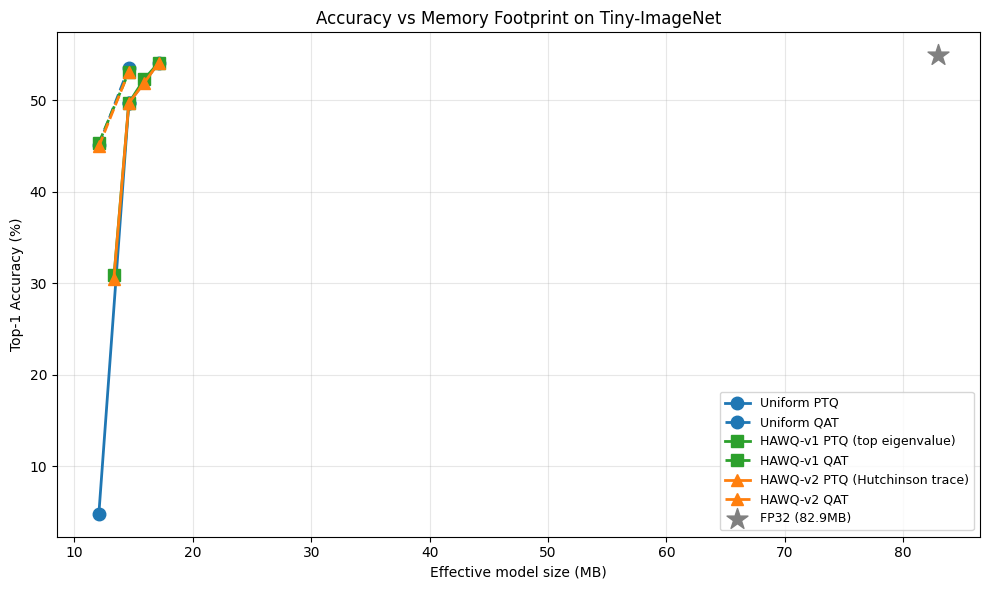

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

for prefix, qat in [
    ('Uniform', False), ('Uniform', True),
    ('HAWQv1', False), ('HAWQv1', True),
    ('HAWQv2', False), ('HAWQv2', True),
]:
    sub = slice_by_method(prefix, qat)
    if len(sub) == 0:
        continue
    key = f'{prefix}-' + ('QAT' if qat else 'PTQ')
    ax.plot(sub['size_mb'], sub['accuracy'] * 100, **styles[key], linewidth=2, markersize=9)

ax.scatter([fp32_size_mb], [fp32_acc * 100], color='gray', marker='*', s=250,
           label=f'FP32 ({fp32_size_mb:.1f}MB)', zorder=5)
ax.set_xlabel('Effective model size (MB)')
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('Accuracy vs Memory Footprint on Tiny-ImageNet')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'accuracy_vs_size.png', dpi=140, bbox_inches='tight')
plt.show()

## 16. Plot 3 — Bit-allocation heatmap (HAWQ-v1 vs HAWQ-v2)

Which layers does each method protect? Rows = layers (sensitivity-sorted by v2),
columns = budgets, cells = bit-width assigned.

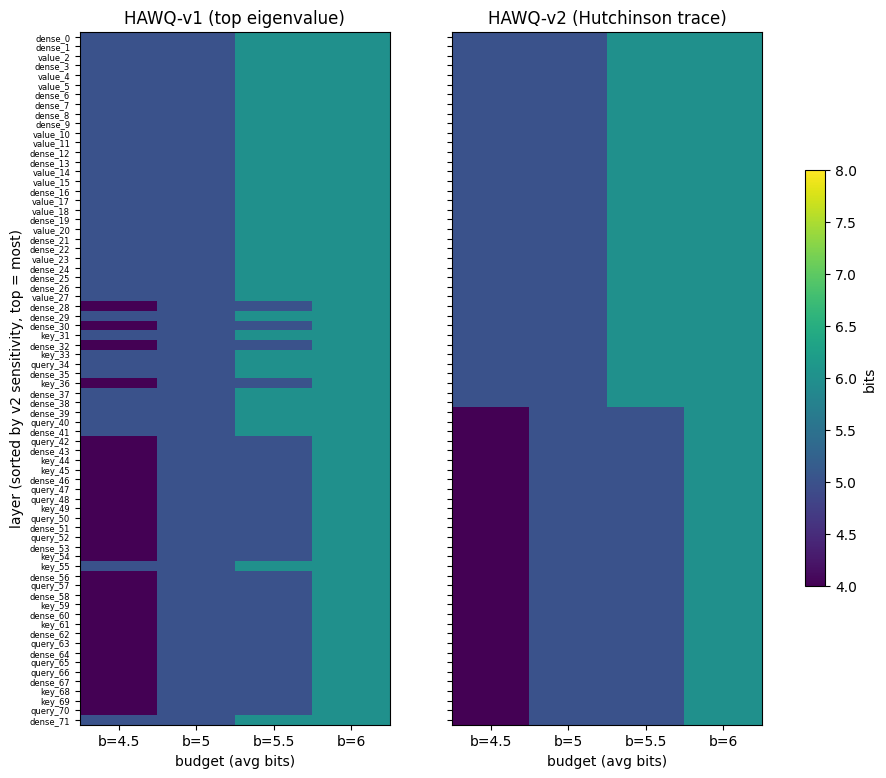

In [35]:
layer_names_sorted = list(sens_v2.keys())

v1_grid = np.zeros((len(layer_names_sorted), len(BUDGETS)))
v2_grid = np.zeros((len(layer_names_sorted), len(BUDGETS)))
for j, b in enumerate(BUDGETS):
    a1 = bit_assignments.get(f'HAWQv1-{b}-PTQ', {})
    a2 = bit_assignments.get(f'HAWQv2-{b}-PTQ', {})
    for i, name in enumerate(layer_names_sorted):
        v1_grid[i, j] = a1.get(name, 0)
        v2_grid[i, j] = a2.get(name, 0)

fig, axes = plt.subplots(1, 2, figsize=(11, 9), sharey=True)
vmin, vmax = min(CANDIDATE_BITS), max(CANDIDATE_BITS)
for ax, grid, title in zip(axes, [v1_grid, v2_grid],
                            ['HAWQ-v1 (top eigenvalue)', 'HAWQ-v2 (Hutchinson trace)']):
    im = ax.imshow(grid, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(BUDGETS)))
    ax.set_xticklabels([f'b={b}' for b in BUDGETS])
    ax.set_title(title)
    ax.set_xlabel('budget (avg bits)')
axes[0].set_ylabel('layer (sorted by v2 sensitivity, top = most)')
axes[0].set_yticks(range(len(layer_names_sorted)))
axes[0].set_yticklabels([n.split('.')[-1] + '_' + str(i) for i, n in enumerate(layer_names_sorted)],
                        fontsize=6)
fig.colorbar(im, ax=axes, label='bits', shrink=0.6)
plt.savefig(PLOTS_DIR / 'bit_allocation.png', dpi=140, bbox_inches='tight')
plt.show()

## 17. Plot 4 — Sensitivity ranking agreement

Per-layer scatter of HAWQ-v1 score vs HAWQ-v2 score. Points along the diagonal
mean the two methods agree on which layers are sensitive.

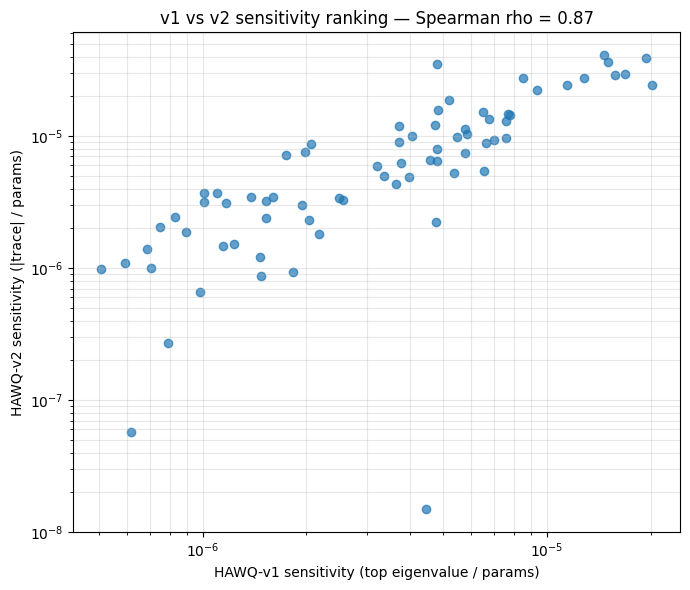

Spearman correlation between v1 and v2 sensitivity ranks: 0.865


In [36]:
from scipy.stats import spearmanr

common = [n for n in sens_v1 if n in sens_v2]
v1_S = np.array([sens_v1[n]['S_i'] for n in common])
v2_S = np.array([sens_v2[n]['S_i'] for n in common])

rho, _ = spearmanr(v1_S, v2_S)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(v1_S, v2_S, alpha=0.7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('HAWQ-v1 sensitivity (top eigenvalue / params)')
ax.set_ylabel('HAWQ-v2 sensitivity (|trace| / params)')
ax.set_title(f'v1 vs v2 sensitivity ranking — Spearman rho = {rho:.2f}')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sensitivity_agreement.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Spearman correlation between v1 and v2 sensitivity ranks: {rho:.3f}')

## 18. Save model state for downstream notebooks (slider, etc.)

In [37]:
ptq.disable_all_quantization(model)
torch.save({
    'state_dict': model.state_dict(),
    'target_names': target_names,
    'sensitivities_v1': sens_v1,
    'sensitivities_v2': sens_v2,
    'fp32_acc': fp32_acc,
    'fp32_size_mb': fp32_size_mb,
    'bit_assignments': bit_assignments,
}, str(OUT_DIR / 'compare_checkpoint.pt'))

print('All artifacts saved:')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(REPO_ROOT)}  ({p.stat().st_size/1024:.1f} KB)')

All artifacts saved:
  compare/bit_assignments.json  (66.3 KB)
  compare/compare_checkpoint.pt  (85050.7 KB)
  compare/plots/accuracy_vs_bits.png  (95.4 KB)
  compare/plots/accuracy_vs_size.png  (70.6 KB)
  compare/plots/bit_allocation.png  (117.5 KB)
  compare/plots/sensitivity_agreement.png  (62.7 KB)
  compare/results.csv  (1.7 KB)
  compare/sensitivities_v1.json  (10.5 KB)
  compare/sensitivities_v2.json  (10.3 KB)
